  Sample_ID    Group  Escherichia_coli  Lactobacillus_spp  \
0        S1  Healthy                56                 31   
1        S2  Healthy                19                 58   
2        S3  Healthy                76                 68   
3        S4  Healthy                65                 51   
4        S5  Healthy                25                 69   

   Staphylococcus_aureus  Bacillus_subtilis  Pseudomonas_aeruginosa  
0                     18                  6                      62  
1                      4                 10                      40  
2                     25                 58                      53  
3                     14                 46                      24  
4                      9                  8                      26  

Dataset salvo com sucesso.
       Escherichia_coli  Lactobacillus_spp  Staphylococcus_aureus  \
count         20.000000          20.000000              20.000000   
mean          43.050000          55.200000     

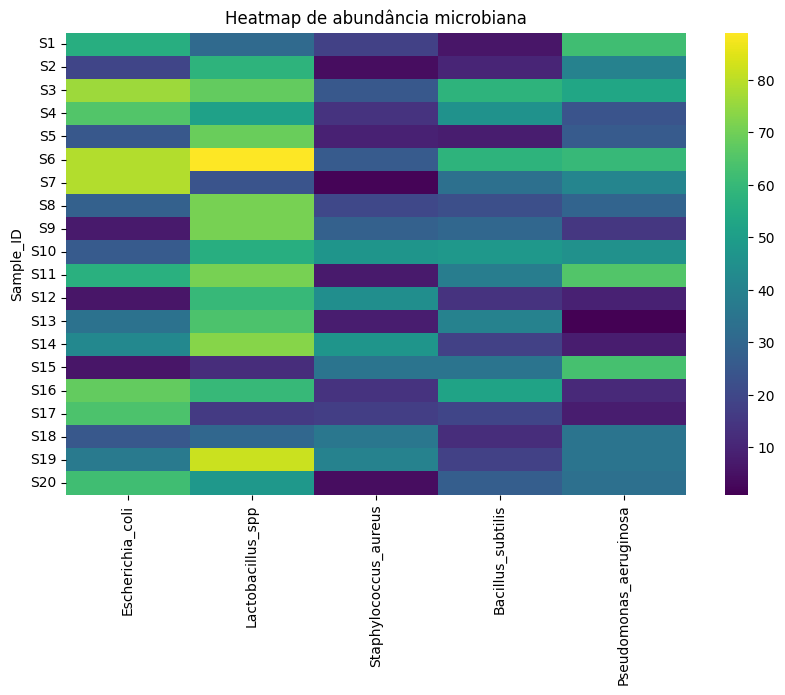

        PC1       PC2    Group
0  0.123522 -1.840548  Healthy
1 -0.664143 -1.010558  Healthy
2  2.103740  1.108042  Healthy
3  1.199609  0.037488  Healthy
4 -0.915916 -0.444333  Healthy


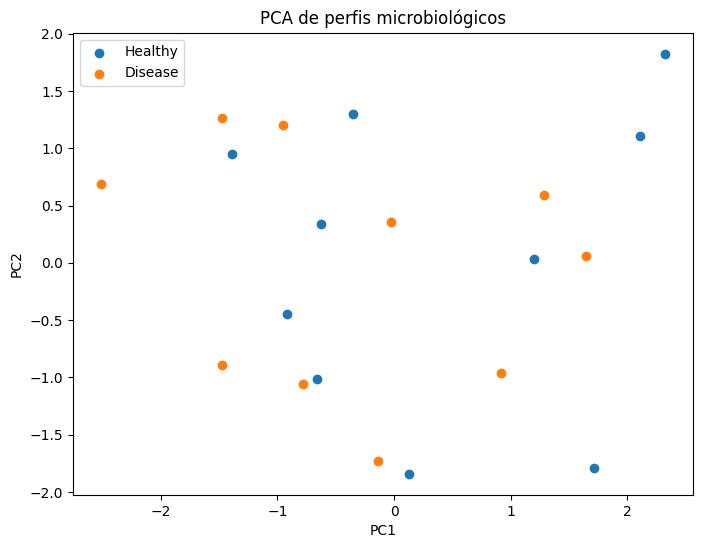

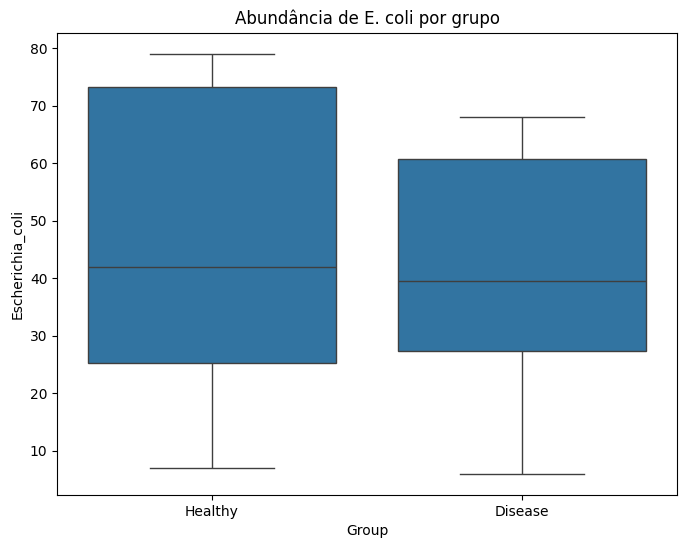

In [14]:
# =========================
# MICROBIOME DATA ANALYSIS
# =========================
#
# Análise exploratória de dados microbiológicos
# simulando abundância bacteriana em grupos
# Healthy e Disease.
#
# =========================

# =========================
# IMPORTAÇÃO DE BIBLIOTECAS
# =========================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# =========================
# CRIAÇÃO DO DATASET MICROBIOLÓGICO
# =========================
#
# Simulação de abundância bacteriana
# em amostras microbiológicas.
#
# =========================

np.random.seed(42)

dados = {
    'Sample_ID': [f'S{i}' for i in range(1, 21)],

    'Group': ['Healthy'] * 10 + ['Disease'] * 10,

    'Escherichia_coli': np.random.randint(5, 80, 20),

    'Lactobacillus_spp': np.random.randint(10, 90, 20),

    'Staphylococcus_aureus': np.random.randint(1, 50, 20),

    'Bacillus_subtilis': np.random.randint(5, 60, 20),

    'Pseudomonas_aeruginosa': np.random.randint(1, 70, 20)
}

df = pd.DataFrame(dados)

# =========================
# VISUALIZAÇÃO INICIAL
# =========================
#
# Visualização das primeiras linhas
# do dataset microbiológico.
#
# =========================

print(df.head())

# =========================
# SALVAR DATASET
# =========================

df.to_csv('microbiome_dataset.csv', index=False)

print("\nDataset salvo com sucesso.")

# =========================
# ESTATÍSTICAS DESCRITIVAS
# =========================
#
# Resumo estatístico das abundâncias
# bacterianas presentes no dataset.
#
# =========================

print(df.describe())

# =========================
# MÉDIA BACTERIANA POR GRUPO
# =========================
#
# Comparação de abundância média
# entre grupos Healthy e Disease.
#
# =========================

medias = df.groupby('Group').mean(numeric_only=True)

print(medias)

# =========================
# HEATMAP MICROBIOLÓGICO
# =========================
#
# Visualização da abundância relativa
# bacteriana entre amostras.
#
# =========================

dados_heatmap = df.set_index('Sample_ID').drop(columns=['Group'])

plt.figure(figsize=(10,6))

sns.heatmap(
    dados_heatmap,
    cmap='viridis'
)

plt.title('Heatmap de abundância microbiana')

plt.savefig(
    'heatmap_microbiome.png',
    bbox_inches='tight'
)

plt.show()

# =========================
# PCA MICROBIOLÓGICO
# =========================
#
# Análise de componentes principais
# para avaliar diferenças entre grupos.
#
# =========================

# remover colunas não numéricas
X = df.drop(columns=['Sample_ID', 'Group'])

# padronização
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2)

principal_components = pca.fit_transform(X_scaled)

# criar dataframe PCA
pca_df = pd.DataFrame(
    data=principal_components,
    columns=['PC1', 'PC2']
)

# adicionar grupos
pca_df['Group'] = df['Group']

print(pca_df.head())

# =========================
# GRÁFICO PCA
# =========================
#
# Visualização bidimensional dos
# perfis microbiológicos.
#
# =========================

plt.figure(figsize=(8,6))

for grupo in pca_df['Group'].unique():

    subset = pca_df[pca_df['Group'] == grupo]

    plt.scatter(
        subset['PC1'],
        subset['PC2'],
        label=grupo
    )

plt.xlabel('PC1')
plt.ylabel('PC2')

plt.title('PCA de perfis microbiológicos')

plt.legend()

plt.savefig(
    'pca_microbiome.png',
    bbox_inches='tight'
)

plt.show()

# =========================
# BOXPLOT MICROBIOLÓGICO
# =========================
#
# Comparação da abundância de
# Escherichia coli entre grupos.
#
# =========================

plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x='Group',
    y='Escherichia_coli'
)

plt.title('Abundância de E. coli por grupo')

plt.savefig(
    'boxplot_ecoli.png',
    bbox_inches='tight'
)

plt.show()

# =========================
# INTERPRETAÇÃO BIOLÓGICA
# =========================
#
# O PCA sugere diferenças nos perfis
# microbiológicos entre os grupos
# Healthy e Disease.
#
# O heatmap demonstra variação na
# abundância bacteriana entre amostras,
# enquanto o boxplot evidencia diferenças
# na distribuição de E. coli entre grupos.
#
# =========================